# LSTM Model Training Notebook

Train the dynamic hand-sign LSTM model using preprocessed sequence data and save artifacts used by the backend.

## Prerequisites

**Required files** (must be available before training):
- `data/X_data.npy` — Preprocessed sequences of hand landmarks
- `data/y_data.npy` — Corresponding class labels
- `models/wlasl_labels.npy` (optional) — Human-readable class names

## Where to Run

### Google Colab ☁️
✓ Recommended for quick experiments without local setup  
→ Follow the **"For Google Colab"** section in execution order

### Local (VS Code, Jupyter, PyCharm) 💻
✓ Recommended if you have data locally and want full control  
→ Follow the **"For Local"** section in execution order

The notebook auto-detects your environment and shows appropriate instructions.

## Install and Import Dependencies

## Recommended Execution Order

### For Local (VS Code, PyCharm, etc.):
1. Cell 4 (imports)
2. Cell 5 (environment check) — will show where data files should be
3. Cell 6 (path discovery & load) — finds and loads your data automatically
4. Cell 7 (data validation) — validates dataset integrity
5. Continue with cells 10, 11, 13... in the order shown in the training flow

### For Google Colab:
1. Cell 4 (imports + Colab setup check)
2. **Cell 5 (upload helper) — Run THIS FIRST to upload data files**
3. Cell 6 (path discovery & load) — finds the uploaded data
4. Cell 7 (data validation) — validates dataset integrity
5. Continue with the training flow below

**Do NOT skip cell 5 in Colab!** The upload widget will guide you through uploading the required .npy files.

### Full Training Flow (after data is loaded):
- Cell 10 (preprocess labels)
- Cell 21 (define model)
- Cell 19 (configure optimizer/loss/callbacks)
- Cell 18 (train model)
- Cell 16 (evaluate model)
- Cell 14 (save artifacts)
- Cell 15 (summary output)

In [9]:
# Uncomment if TensorFlow is missing in your current kernel environment.
# %pip install -q tensorflow numpy scikit-learn matplotlib seaborn

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('Timestamp:', datetime.now().isoformat(timespec='seconds'))

TensorFlow version: 2.19.0
Timestamp: 2026-03-28T09:34:14


In [10]:

# Auto-setup for Colab: check environment and prepare data folder
import sys
import os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
print(f'Environment: {"Google Colab" if IN_COLAB else "Local"}')

# Create data and models directories
Path('data').mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)

# If in Colab and data files missing, prepare for upload
if IN_COLAB:
    x_exists = Path('data/X_data.npy').exists()
    y_exists = Path('data/y_data.npy').exists()
    
    if not (x_exists and y_exists):
        print('\n⚠️  Colab detected. Data files not found in ./data/')
        print('Next step: Run the cell below to upload X_data.npy and y_data.npy')
    else:
        print('✓ Data files found in ./data/')
else:
    print('Running locally. Path discovery will search for data files.')


Environment: Google Colab

⚠️  Colab detected. Data files not found in ./data/
Next step: Run the cell below to upload X_data.npy and y_data.npy


In [11]:
import os
from pathlib import Path

cwd = Path.cwd()
required = [Path('data') / 'X_data.npy', Path('data') / 'y_data.npy']

def has_required_files(root: Path) -> bool:
    return all((root / rel).exists() for rel in required)

def add_candidate(path_value, bucket, seen):
    if not path_value:
        return
    try:
        candidate = Path(path_value).expanduser()
    except (TypeError, ValueError):
        return
    key = str(candidate)
    if key not in seen:
        seen.add(key)
        bucket.append(candidate)

def try_mount_colab_drive():
    if cwd.as_posix().startswith('/content') and not Path('/content/drive').exists():
        try:
            from google.colab import drive  # type: ignore
            drive.mount('/content/drive')
        except Exception:
            pass

def discover_from_roots(search_roots):
    for root in search_roots:
        if not root.exists():
            continue
        if has_required_files(root):
            return root
        try:
            for data_dir in root.rglob('data'):
                if data_dir.is_dir():
                    parent = data_dir.parent
                    if has_required_files(parent):
                        return parent
        except (OSError, PermissionError):
            continue
    return None

def discover_colab_drive_project(colab_drive_root: Path):
    if not colab_drive_root.exists():
        return None
    # Fast path: common direct locations under Drive.
    direct_candidates = [
        colab_drive_root / 'MyDrive' / 'hand_sign_detection_dynamic',
        colab_drive_root / 'MyDrive' / 'Colab Notebooks' / 'hand_sign_detection_dynamic',
        colab_drive_root / 'MyDrive' / 'HandSignDetectionDynamic',
    ]
    for candidate in direct_candidates:
        if has_required_files(candidate):
            return candidate

    # Robust fallback: search for canonical data files in any nested project.
    try:
        for x_file in colab_drive_root.rglob('X_data.npy'):
            if x_file.parent.name != 'data':
                continue
            repo_root = x_file.parent.parent
            if has_required_files(repo_root):
                return repo_root
    except (OSError, PermissionError):
        pass
    return None

def pick_dataset_file(data_dir: Path, base_name: str):
    exact = data_dir / f'{base_name}.npy'
    if exact.exists():
        return exact

    candidates = sorted(data_dir.glob(f'{base_name}_*.npy'))
    if candidates:
        # Parse YYYYMMDD_HHMMSS timestamp from filename instead of using mtime.
        # Expected format: X_data_20260313_223231.npy
        def extract_timestamp(path):
            name = path.stem  # e.g., 'X_data_20260313_223231'
            parts = name.split('_')
            if len(parts) >= 3:
                try:
                    # Last two parts should be YYYYMMDD and HHMMSS
                    timestamp_str = parts[-2] + parts[-1]  # '20260313223231'
                    return int(timestamp_str)
                except (ValueError, IndexError):
                    return 0
            return 0
        
        return max(candidates, key=extract_timestamp)
    return None

def discover_dataset_pair(search_roots):
    for root in search_roots:
        if not root.exists():
            continue
        try:
            for data_dir in root.rglob('data'):
                if not data_dir.is_dir():
                    continue
                x_candidate = pick_dataset_file(data_dir, 'X_data')
                y_candidate = pick_dataset_file(data_dir, 'y_data')
                if x_candidate is not None and y_candidate is not None:
                    return x_candidate, y_candidate
        except (OSError, PermissionError):
            continue
    return None, None

try_mount_colab_drive()

candidates = []
seen = set()

# 1) Explicit override if provided.
add_candidate(os.getenv('HAND_SIGN_REPO_ROOT'), candidates, seen)

# 2) Walk up from cwd.
for candidate in [cwd, *cwd.parents]:
    add_candidate(candidate, candidates, seen)

# 3) Common roots in local/WSL/container/Colab (generic paths only).
for candidate in [
    Path('/content/hand_sign_detection_dynamic'),
    Path('/content/drive/MyDrive/hand_sign_detection_dynamic'),
    Path('/content/drive/MyDrive/Colab Notebooks/hand_sign_detection_dynamic'),
    Path('/workspace/hand_sign_detection_dynamic'),
    Path('/workspaces/hand_sign_detection_dynamic'),
    Path('/app'),
]:
    add_candidate(candidate, candidates, seen)

project_root = next((c for c in candidates if has_required_files(c)), None)

scan_roots = [
    Path('/content'),
    Path('/content/drive'),
    Path('/content/drive/MyDrive'),
    Path('/tmp'),
    Path('/mnt'),
    Path('/workspace'),
    Path('/workspaces'),
    Path('/home'),
    Path('/root'),
]
if project_root is None:
    project_root = discover_from_roots(scan_roots)

if project_root is None and cwd.as_posix().startswith('/content'):
    project_root = discover_colab_drive_project(Path('/content/drive'))

# Resolve dataset paths either from canonical file names or timestamped variants.
x_path = None
y_path = None
if project_root is not None:
    x_path = pick_dataset_file(project_root / 'data', 'X_data')
    y_path = pick_dataset_file(project_root / 'data', 'y_data')

if x_path is None or y_path is None:
    x_path, y_path = discover_dataset_pair(scan_roots)
    if x_path is not None and y_path is not None:
        project_root = x_path.parent.parent

if x_path is None or y_path is None or project_root is None:
    attempted = '\n'.join(f' - {c}' for c in candidates)
    scanned = '\n'.join(f' - {r}' for r in scan_roots if r.exists())
    raise FileNotFoundError(
        'Could not locate X/y dataset files in this kernel environment.\n'
        f'cwd={cwd}\n'
        f'Tried candidate roots:\n{attempted}\n'
        f'Scanned roots:\n{scanned}\n'
        'Expected files include data/X_data.npy + data/y_data.npy or timestamped variants like data/X_data_*.npy + data/y_data_*.npy.'
    )

labels_candidates = [
    project_root / 'models' / 'wlasl_labels.npy',
    project_root / 'data' / 'wlasl_labels.npy',
]
labels_path = next((p for p in labels_candidates if p.exists()), None)

X = np.load(x_path)
y = np.load(y_path)
class_names = np.load(labels_path, allow_pickle=True) if labels_path is not None else None

print('Resolved project_root:', project_root)
print('Using X file:', x_path.name)
print('Using y file:', y_path.name)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Labels available:', class_names is not None)
if class_names is not None:
    print('Number of class names:', len(class_names))

Resolved project_root: /content/drive/MyDrive/training
Using X file: X_data.npy
Using y file: y_data.npy
X shape: (11, 30, 8)
y shape: (11,)
Labels available: True
Number of class names: 10


In [14]:
def validate_dataset_pair(X, y, labels=None, expected_seq_len=None, expected_feature_dim=None):
    """
    Validate dataset integrity before training.
    Raises ValueError with clear messages if validation fails.
    """
    errors = []
    warnings = []
    
    # Check shapes
    if X.ndim != 3:
        errors.append(f'X must be 3D (sequences, seq_length, features), got {X.ndim}D with shape {X.shape}')
    if y.ndim != 1:
        errors.append(f'y must be 1D (class labels), got {y.ndim}D with shape {y.shape}')
    
    if errors:
        raise ValueError('\n'.join(errors))
    
    # Check consistency
    if X.shape[0] != y.shape[0]:
        errors.append(f'X and y must have same number of samples: X.shape[0]={X.shape[0]}, y.shape[0]={y.shape[0]}')
    
    # Check dtypes
    if X.dtype not in [np.float32, np.float64]:
        errors.append(f'X should be float32 or float64, got {X.dtype}')
    if not np.issubdtype(y.dtype, np.integer):
        errors.append(f'y should be integer type, got {y.dtype}')
    
    # Check value ranges
    num_classes = int(np.max(y) + 1)
    if np.min(y) < 0:
        errors.append(f'y contains negative class indices: min={np.min(y)}')
    
    # Check class balance
    unique_classes, counts = np.unique(y, return_counts=True)
    min_samples = int(counts.min())
    max_samples = int(counts.max())
    if min_samples < 1:
        errors.append(f'Some classes have no samples')
    if min_samples < 2:
        warnings.append(f'⚠ Minimum class count is {min_samples}; will use stratify=None for train/test split')
    
    # Check for NaN/Inf
    if np.isnan(X).any():
        errors.append(f'X contains NaN values')
    if np.isinf(X).any():
        errors.append(f'X contains infinite values')
    
    if errors:
        raise ValueError('\n'.join(errors))
    
    # Print validation summary
    print('✓ Dataset validation passed')
    print(f'  Samples: {X.shape[0]}')
    print(f'  Sequence length: {X.shape[1]}')
    print(f'  Feature dimension: {X.shape[2]}')
    print(f'  Classes: {len(unique_classes)}')
    print(f'  Class distribution: min={min_samples}, max={max_samples}')
    
    if labels is not None:
        if len(labels) != num_classes:
            print(f'  ⚠ Warning: {len(labels)} labels provided but {num_classes} classes in y')
        else:
            print(f'  Labels match class count ✓')
    
    # Print warnings (non-blocking)
    for warning in warnings:
        print(warning)
    
    return True

# Validate loaded data immediately
validate_dataset_pair(X, y, labels=class_names)

✓ Dataset validation passed
  Samples: 11
  Sequence length: 30
  Feature dimension: 8
  Classes: 6
  Class distribution: min=1, max=3
  Labels match class count ✓
⚠ Minimum class count is 1; will use stratify=None for train/test split


True

In [15]:
# Upload data files for Colab
# Run this cell if you see "Data files not found" above

from pathlib import Path
import shutil

print('Preparing upload widget...\n')
print('You will be prompted to select files.')
print('Required files:')
print('  1. X_data.npy')
print('  2. y_data.npy')
print('  3. wlasl_labels.npy (optional but recommended)\n')

data_dir = Path('data')
models_dir = Path('models')
data_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

x_dst = data_dir / 'X_data.npy'
y_dst = data_dir / 'y_data.npy'
labels_dst = models_dir / 'wlasl_labels.npy'

# Check if files already exist
if x_dst.exists() and y_dst.exists():
    print('✓ Dataset already exists in ./data')
else:
    try:
        from google.colab import files  # type: ignore
        print('Click "Choose Files" button and select the .npy files from your computer.\n')
        uploaded = files.upload()
        
        if not uploaded:
            print('No files uploaded. Skipping.')
        else:
            for fname in uploaded.keys():
                src = Path(fname)
                lower = fname.lower()
                print(f'Processing: {fname}')
                
                if lower.endswith('x_data.npy'):
                    shutil.move(str(src), str(x_dst))
                    print(f'  ✓ Saved to {x_dst}')
                elif lower.endswith('y_data.npy'):
                    shutil.move(str(src), str(y_dst))
                    print(f'  ✓ Saved to {y_dst}')
                elif lower.endswith('wlasl_labels.npy'):
                    shutil.move(str(src), str(labels_dst))
                    print(f'  ✓ Saved to {labels_dst}')
                else:
                    print(f'  ⚠ Unrecognized file (expected *_data.npy or *_labels.npy)')
                    
    except ImportError:
        print('❌ Upload widget unavailable (not in Colab)')
        print('Copy files manually to ./data and run this cell again.')
    except Exception as e:
        print(f'Error during upload: {e}')

# Verify files
print('\n📊 File status:')
print(f'  X_data.npy: {"✓" if x_dst.exists() else "✗"}')
print(f'  y_data.npy: {"✓" if y_dst.exists() else "✗"}')
print(f'  wlasl_labels.npy: {"✓" if labels_dst.exists() else "⊘ (optional)"}')

if x_dst.exists() and y_dst.exists():
    print('\n✓ Ready! Run the next cell (path discovery) to load the data.')
else:
    print('\n⚠ Required files still missing. Please upload and try again.')

Preparing upload widget...

You will be prompted to select files.
Required files:
  1. X_data.npy
  2. y_data.npy
  3. wlasl_labels.npy (optional but recommended)

Click "Choose Files" button and select the .npy files from your computer.



KeyboardInterrupt: 

## Load Dataset

Sequence length: 30
Feature dimension: 8
Total samples: 11
Number of unique classes: 6
Minimum class count: 1
Maximum class count: 3


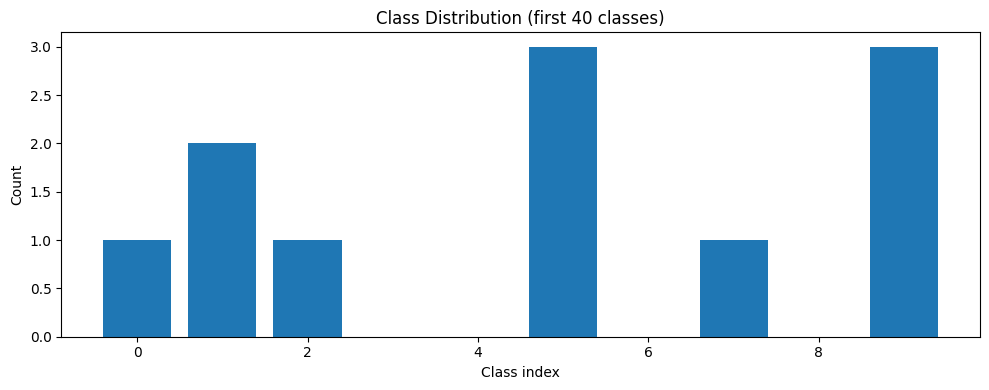

In [16]:
print('Sequence length:', X.shape[1])
print('Feature dimension:', X.shape[2])
print('Total samples:', X.shape[0])

unique_classes, counts = np.unique(y, return_counts=True)
print('Number of unique classes:', len(unique_classes))
print('Minimum class count:', int(counts.min()))
print('Maximum class count:', int(counts.max()))

plt.figure(figsize=(10, 4))
plt.bar(unique_classes[:40], counts[:40])
plt.title('Class Distribution (first 40 classes)')
plt.xlabel('Class index')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Split Data into Train and Validation Sets

In [19]:
if 'y_cat' not in globals():
    num_classes = int(len(np.unique(y)))
    y_cat = to_categorical(y, num_classes=num_classes)

use_stratify = np.bincount(y).min() >= 2
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y if use_stratify else None,
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)

Train: (8, 30, 8) (8, 10)
Validation: (3, 30, 8) (3, 10)


## Preprocess Features and Labels

In [18]:
num_classes = int(np.max(y) + 1)  # Use max index + 1 instead of unique count
y_cat = to_categorical(y, num_classes=num_classes)

print('X dtype:', X.dtype)
print('y categorical shape:', y_cat.shape)
print('num_classes:', num_classes)
print('Actual unique classes in y:', np.unique(y))

X dtype: float32
y categorical shape: (11, 10)
num_classes: 10
Actual unique classes in y: [0 1 2 5 7 9]


## Define Model Architecture

## Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Set up callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print('Starting LSTM training...')
print(f'Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}')

# Train the model with live dashboard callback
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=2,
    callbacks=[early_stopping, LiveTrainingCallback(epochs=50, title='LSTM Training', show_live_plot=True)],
    verbose=0
)

print('\nTraining complete')

Starting LSTM training...
Training samples: 8, Validation samples: 3

🚀 Starting LSTM Training


Epoch   1/50   0% |                                              | 0/4 [00:00<?]

  Epoch   1/50 | loss:  2.2974 | acc:  0.1250 | val_loss:  2.2206 | val_acc:  0.3333 | [  5s /    5s]


Epoch   2/50   0% |                                              | 0/4 [00:00<?]

  Epoch   2/50 | loss:  2.2015 | acc:  0.2500 | val_loss:  2.1647 | val_acc:  0.3333 | [  0s /    6s] ↓


...

  Epoch   9/50 | loss:  1.6076 | acc:  0.2500 | val_loss:  2.2027 | val_acc:  0.3333 | [  0s /    7s] ↑


Epoch  10/50   0% |                                              | 0/4 [00:00<?]

  Epoch  10/50 | loss:  1.7383 | acc:  0.2500 | val_loss:  2.3140 | val_acc:  0.3333 | [  0s /    8s] ↑


Epoch  11/50   0% |                                              | 0/4 [00:00<?]

  Epoch  11/50 | loss:  1.5737 | acc:  0.3750 | val_loss:  2.1591 | val_acc:  0.3333 | [  0s /    8s] ↓
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.
✅ Training Complete!
   Total Time: 8s ( 0.14 minutes)
   Final Val Loss: 2.1591
   Final Val Accuracy: 0.3333


✓ Training complete!


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Define LSTM model architecture
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile with Adam optimizer
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully')
model.summary()

Model compiled successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,730 (526.29 KB)

 Trainable params: 134,730 (526.29 KB)

 Non-trainable params: 0 (0.00 B)

## Save Trained Model and Artifacts

In [25]:
required = [
    'project_root', 'model', 'history', 'x_path', 'y_path',
    'X', 'num_classes', 'val_loss', 'val_acc'
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects before saving: {missing}')

if 'target_names' not in globals():
    if class_names is not None and len(class_names) == num_classes:
        target_names = [str(x) for x in class_names]
    else:
        target_names = [f'class_{i}' for i in range(num_classes)]

models_dir = project_root / 'models'
reports_dir = project_root / 'reports'
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

lstm_model_path = models_dir / 'gesture_model.h5'
labels_out_path = models_dir / 'wlasl_labels.npy'
metadata_path = reports_dir / f"lstm_training_metadata_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

model.save(lstm_model_path)

if class_names is not None and len(class_names) == num_classes:
    np.save(labels_out_path, class_names)
else:
    np.save(labels_out_path, np.array(target_names))

history_dict = {k: [float(vv) for vv in v] for k, v in history.history.items()}

metadata = {
    'created_at': datetime.now().isoformat(),
    'x_data_path': str(x_path),
    'y_data_path': str(y_path),
    'model_path': str(lstm_model_path),
    'labels_path': str(labels_out_path),
    'input_shape': [int(X.shape[1]), int(X.shape[2])],
    'num_classes': int(num_classes),
    'validation_loss': float(val_loss),
    'validation_accuracy': float(val_acc),
    'epochs_ran': int(len(history_dict.get('loss', []))),
    'history': history_dict,
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved LSTM model:', lstm_model_path)
print('Saved class labels:', labels_out_path)
print('Saved metadata:', metadata_path)

Saved LSTM model: /content/drive/MyDrive/training/models/gesture_model.h5
Saved class labels: /content/drive/MyDrive/training/models/wlasl_labels.npy
Saved metadata: /content/drive/MyDrive/training/reports/lstm_training_metadata_20260328_094358.json


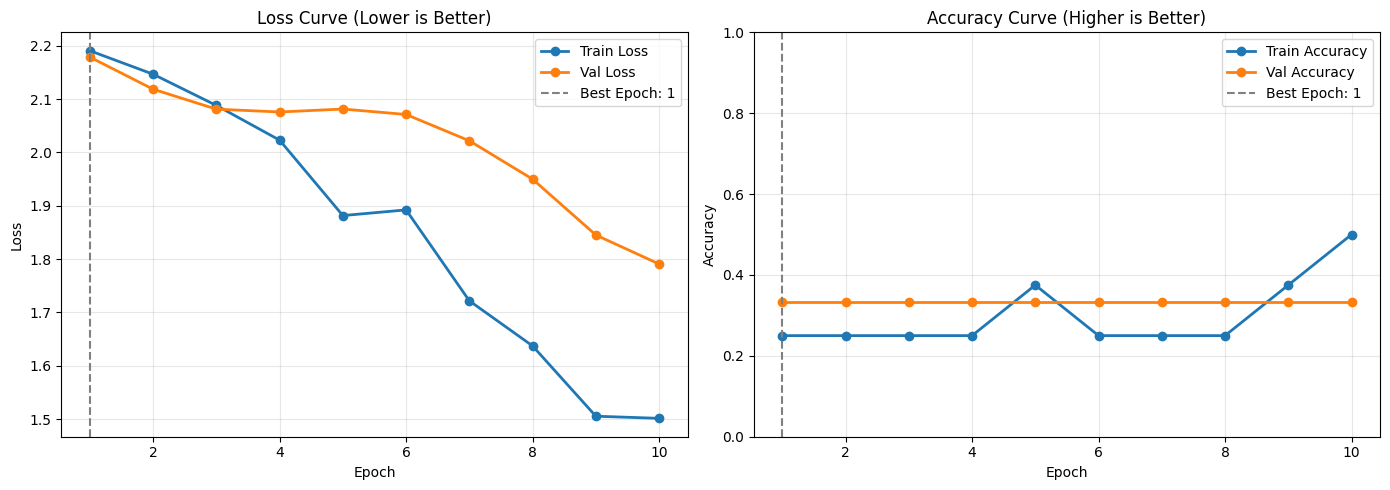

Best epoch by val_accuracy: 1
Best validation accuracy: 0.3333


{'samples': 11,
 'sequence_length': 30,
 'feature_dim': 8,
 'num_classes': 10,
 'val_accuracy': 0.3333333432674408,
 'model_path': '/content/drive/MyDrive/training/models/gesture_model.h5',
 'metadata_path': '/content/drive/MyDrive/training/reports/lstm_training_metadata_20260328_094358.json'}

In [28]:
required = ['history', 'X', 'num_classes', 'val_acc', 'lstm_model_path', 'metadata_path']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects before summary: {missing}')


def plot_training_history(history_obj):
    hist = history_obj.history
    train_loss = hist.get('loss', [])
    val_loss_hist = hist.get('val_loss', [])
    train_acc = hist.get('accuracy', [])
    val_acc_hist = hist.get('val_accuracy', [])

    if not train_loss:
        raise RuntimeError('History is empty. Train the model first.')

    epochs_idx = np.arange(1, len(train_loss) + 1)
    best_epoch = int(np.argmax(val_acc_hist) + 1) if val_acc_hist else len(train_loss)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_idx, train_loss, marker='o', linewidth=2, label='Train Loss')
    if val_loss_hist:
        axes[0].plot(epochs_idx, val_loss_hist, marker='o', linewidth=2, label='Val Loss')
    axes[0].axvline(best_epoch, linestyle='--', linewidth=1.5, color='gray', label=f'Best Epoch: {best_epoch}')
    axes[0].set_title('Loss Curve (Lower is Better)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs_idx, train_acc, marker='o', linewidth=2, label='Train Accuracy')
    if val_acc_hist:
        axes[1].plot(epochs_idx, val_acc_hist, marker='o', linewidth=2, label='Val Accuracy')
    axes[1].axvline(best_epoch, linestyle='--', linewidth=1.5, color='gray', label=f'Best Epoch: {best_epoch}')
    axes[1].set_title('Accuracy Curve (Higher is Better)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'Best epoch by val_accuracy: {best_epoch}')
    if val_acc_hist:
        print(f'Best validation accuracy: {max(val_acc_hist):.4f}')


plot_training_history(history)

summary = {
    'samples': int(X.shape[0]),
    'sequence_length': int(X.shape[1]),
    'feature_dim': int(X.shape[2]),
    'num_classes': int(num_classes),
    'val_accuracy': float(val_acc),
    'model_path': str(lstm_model_path),
    'metadata_path': str(metadata_path),
}
summary

Validation loss: 2.22057843208313
Validation accuracy: 0.3333333432674408


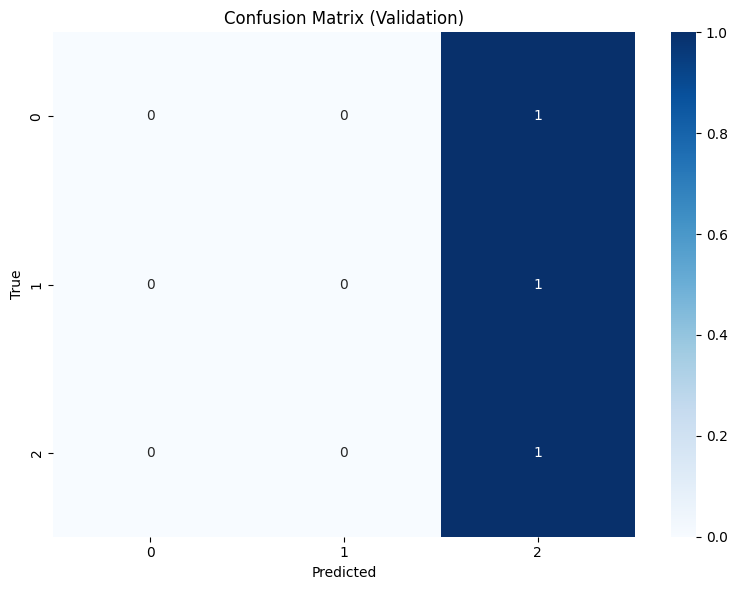

Classification Report (validation set classes only):
              precision    recall  f1-score   support

        book       0.00      0.00      0.00         1
          go       0.00      0.00      0.00         1
      cousin       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



In [24]:
required = ['model', 'X_val', 'y_val', 'num_classes']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects before evaluation: {missing}')

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
y_val_pred_probs = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)
y_val_true = np.argmax(y_val, axis=1)

print('Validation loss:', float(val_loss))
print('Validation accuracy:', float(val_acc))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap='Blues', cbar=True, annot=True, fmt='d')
plt.title('Confusion Matrix (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

if class_names is not None and len(class_names) == num_classes:
    target_names = [str(x) for x in class_names]
else:
    target_names = [f'class_{i}' for i in range(num_classes)]

# Get unique classes in validation set to match target_names size
unique_labels = np.unique(y_val_true)
report = classification_report(
    y_val_true,
    y_val_pred,
    labels=unique_labels,
    target_names=[target_names[i] for i in unique_labels],
    output_dict=True,
    zero_division=0,
)

print('Classification Report (validation set classes only):')
print(classification_report(
    y_val_true,
    y_val_pred,
    labels=unique_labels,
    target_names=[target_names[i] for i in unique_labels],
    zero_division=0,
))

## Evaluate Model Performance

In [26]:
# Live training dashboard callback (works in Colab and Jupyter)
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except Exception:
    widgets = None
    HAS_WIDGETS = False


class LiveTrainingCallback(tf.keras.callbacks.Callback):
    """Keras callback with live progress bars and live training curves."""

    def __init__(self, epochs, title="LSTM Training", show_live_plot=True):
        super().__init__()
        self.epochs = int(epochs)
        self.title = title
        self.show_live_plot = bool(show_live_plot)

        self.start_time = None
        self.epoch_start_time = None
        self.steps_per_epoch = 1

        self.history_loss = []
        self.history_val_loss = []
        self.history_acc = []
        self.history_val_acc = []

        self.epoch_bar = None
        self.batch_bar = None
        self.status_html = None
        self.plot_output = None

    def _format_status(self, epoch, loss, acc, val_loss, val_acc, epoch_seconds, total_seconds):
        return (
            f"<b>{self.title}</b><br>"
            f"Epoch: {epoch + 1}/{self.epochs}<br>"
            f"Loss: {loss:.4f} | Accuracy: {acc:.4f}<br>"
            f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}<br>"
            f"Epoch Time: {epoch_seconds:.1f}s | Total Time: {total_seconds:.1f}s"
        )

    def _render_live_plot(self):
        if not self.plot_output:
            return

        with self.plot_output:
            clear_output(wait=True)
            epochs_idx = np.arange(1, len(self.history_loss) + 1)

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            axes[0].plot(epochs_idx, self.history_loss, marker="o", linewidth=2, label="Train Loss")
            axes[0].plot(epochs_idx, self.history_val_loss, marker="o", linewidth=2, label="Val Loss")
            axes[0].set_title("Loss vs Epoch")
            axes[0].set_xlabel("Epoch")
            axes[0].set_ylabel("Loss")
            axes[0].grid(alpha=0.3)
            axes[0].legend()

            axes[1].plot(epochs_idx, self.history_acc, marker="o", linewidth=2, label="Train Accuracy")
            axes[1].plot(epochs_idx, self.history_val_acc, marker="o", linewidth=2, label="Val Accuracy")
            axes[1].set_title("Accuracy vs Epoch")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("Accuracy")
            axes[1].set_ylim(0.0, 1.0)
            axes[1].grid(alpha=0.3)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.steps_per_epoch = int(self.params.get("steps") or self.params.get("steps_per_epoch") or 1)

        if HAS_WIDGETS:
            self.epoch_bar = widgets.IntProgress(
                value=0,
                min=0,
                max=self.epochs,
                description="Epoch",
                bar_style="info",
                layout=widgets.Layout(width="100%"),
            )
            self.batch_bar = widgets.IntProgress(
                value=0,
                min=0,
                max=max(1, self.steps_per_epoch),
                description="Batch",
                bar_style="",
                layout=widgets.Layout(width="100%"),
            )
            self.status_html = widgets.HTML(value=f"<b>{self.title}</b><br>Waiting for first epoch...")

            if self.show_live_plot:
                self.plot_output = widgets.Output()
                display(widgets.VBox([self.status_html, self.epoch_bar, self.batch_bar, self.plot_output]))
            else:
                display(widgets.VBox([self.status_html, self.epoch_bar, self.batch_bar]))
        else:
            print(f"{self.title}: widgets unavailable, using text fallback.")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()
        if self.batch_bar is not None:
            self.batch_bar.value = 0
            self.batch_bar.max = max(1, self.steps_per_epoch)

    def on_train_batch_end(self, batch, logs=None):
        if self.batch_bar is not None:
            self.batch_bar.value = min(batch + 1, self.batch_bar.max)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        loss = float(logs.get("loss", 0.0))
        acc = float(logs.get("accuracy", 0.0))
        val_loss = float(logs.get("val_loss", 0.0))
        val_acc = float(logs.get("val_accuracy", 0.0))

        self.history_loss.append(loss)
        self.history_acc.append(acc)
        self.history_val_loss.append(val_loss)
        self.history_val_acc.append(val_acc)

        total_seconds = time.time() - self.start_time
        epoch_seconds = time.time() - self.epoch_start_time

        if self.epoch_bar is not None:
            self.epoch_bar.value = epoch + 1
        if self.status_html is not None:
            self.status_html.value = self._format_status(
                epoch, loss, acc, val_loss, val_acc, epoch_seconds, total_seconds
            )

        if self.show_live_plot and HAS_WIDGETS:
            self._render_live_plot()
        else:
            print(
                f"Epoch {epoch + 1}/{self.epochs} | "
                f"loss={loss:.4f} acc={acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )

    def on_train_end(self, logs=None):
        total_seconds = time.time() - self.start_time
        if self.epoch_bar is not None:
            self.epoch_bar.bar_style = "success"
        if self.batch_bar is not None:
            self.batch_bar.bar_style = "success"
        if self.status_html is not None:
            self.status_html.value += f"<br><b>Training complete in {total_seconds:.1f}s</b>"


print("LiveTrainingCallback ready")
print("Features: live epoch/batch bars, live metrics panel, and live loss/accuracy curves")

LiveTrainingCallback ready
Features: live epoch/batch bars, live metrics panel, and live loss/accuracy curves


In [27]:
required = ['model', 'X_train', 'y_train', 'X_val', 'y_val', 'early_stopping']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects before training: {missing}')

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, LiveTrainingCallback(epochs=50, title='LSTM Training', show_live_plot=True)],
    verbose=0,
)

print('Epochs run:', len(history.history['loss']))

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
Epochs run: 10


In [ ]:
model_obj = globals().get('model')
if model_obj is None:
    raise RuntimeError('Model is not defined. Run the model architecture cell first.')

model_obj.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
)

model = model_obj
print('Configured optimizer/loss/metrics and early stopping callback.')

## Configure Loss, Optimizer, and Metrics

In [ ]:
if 'num_classes' not in globals():
    num_classes = int(len(np.unique(y)))

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax'),
])

model.summary()